# مرحله ۱: بارگذاری داده‌ها و آماده‌سازی اولیه

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "Fully_Funded(DC)_Data.xlsx"

xls = pd.ExcelFile(file_path)

assumptions_df = pd.read_excel(file_path, sheet_name="Assumptions")
people_df = pd.read_excel(file_path, sheet_name="People")
life_table_df = pd.read_excel(file_path, sheet_name="Life_table")

print("Sheets:", xls.sheet_names)
print("Assumptions shape:", assumptions_df.shape)
print("People shape:", people_df.shape)
print("Life_table shape:", life_table_df.shape)


Sheets: ['Assumptions', 'Life_table', 'People']
Assumptions shape: (27, 4)
People shape: (100, 8)
Life_table shape: (101, 7)


در این مرحله فایل اکسل پروژه با موفقیت بارگذاری شد و سه شیت اصلی داده‌ها به محیط تحلیل منتقل شدند. این گام برای آماده‌سازی داده‌ها و شروع کنترل ساختار و محاسبات اکچوئریال انجام شد

# مرحله ۲: کنترل ستون‌ها و تمیزسازی اولیه

In [2]:
# بررسی نام ستون‌ها
print("Assumptions columns:", assumptions_df.columns.tolist())
print("People columns:", people_df.columns.tolist())
print("Life_table columns:", life_table_df.columns.tolist())

# تمیزسازی نام ستون‌ها
assumptions_df.columns = assumptions_df.columns.str.strip()
people_df.columns = people_df.columns.str.strip()
life_table_df.columns = life_table_df.columns.str.strip()

# حذف ستون‌های کاملاً خالی
assumptions_df = assumptions_df.dropna(axis=1, how="all")
people_df = people_df.dropna(axis=1, how="all")
life_table_df = life_table_df.dropna(axis=1, how="all")

# نمایش نتیجه
print("\nAfter cleaning:")
print("Assumptions columns:", assumptions_df.columns.tolist())
print("People columns:", people_df.columns.tolist())
print("Life_table columns:", life_table_df.columns.tolist())


Assumptions columns: ['دسته', 'پارامتر', 'مقدار', 'واحد / توضیح']
People columns: ['Member_ID', 'Status', 'Gender', 'Age', 'Entry_Age', 'Service_Years', 'Initial_Salary', 'Initial_Account_Balance']
Life_table columns: ['Age', 'lx', 'qx', 'px', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6']

After cleaning:
Assumptions columns: ['دسته', 'پارامتر', 'مقدار', 'واحد / توضیح']
People columns: ['Member_ID', 'Status', 'Gender', 'Age', 'Entry_Age', 'Service_Years', 'Initial_Salary', 'Initial_Account_Balance']
Life_table columns: ['Age', 'lx', 'qx', 'px', 'Unnamed: 5', 'Unnamed: 6']


در این مرحله، نام ستون‌های هر شیت بررسی شد و سپس ستون‌های دارای فاصله اضافی و ستون‌های کاملاً خالی حذف شدند. هدف این گام، یکپارچه‌سازی ساختار داده‌ها و جلوگیری از خطا در مراحل محاسباتی بعدی است

# مرحله ۳: استخراج مفروضات کلیدی

In [3]:
# حذف ستون‌های اضافی که فقط داده‌ی خالی دارند
assumptions_clean = assumptions_df.dropna(axis=1, how="all").copy()

# نگه‌داشتن دو ستون اصلی و نام‌گذاری خوانا
assumptions_clean = assumptions_clean.iloc[:, :2]
assumptions_clean.columns = ["Parameter", "Value"]

# حذف ردیف‌های کاملاً خالی و مرتب‌سازی شماره ردیف‌ها
assumptions_clean = assumptions_clean.dropna(how="all").reset_index(drop=True)

# نمایش کامل جدول
display(assumptions_df)

,دسته,پارامتر,مقدار,واحد / توضیح
0,ساختار صندوق,Scheme_Type,Fully Funded - DC,طرح مشارکت معین با تأمین مالی کامل
1,اعضا,Number_of_Members,100,نفر
2,سن ورود,Entry_Age_Min,20,سال
3,سن ورود,Entry_Age_Max,40,سال
4,سن بازنشستگی,Normal_Retirement_Age,60,سال
5,سابقه لازم,Minimum_Service_Years,20,سال سابقه برای احراز بازنشستگی
6,افق تحلیل,Projection_Horizon,10,سال
7,نرخ حق‌بیمه کارمند,Employee_Contribution_Rate,0.07,درصد حقوق
8,نرخ حق‌بیمه کارفرما,Employer_Contribution_Rate,0.13,درصد حقوق
9,نرخ حق‌بیمه کل,Total_Contribution_Rate,0.2,جمع سهم کارمند و کارفرما


در این مرحله، داده‌های شیت زیر به جدول استاندارد تبدیل شد

- `Assumptions`
- `Parameter`
- `Value`

این ساختار، خوانایی مفروضات مدل را افزایش می‌دهد

# مرحله ۴: آماده‌سازی شیت "People"

In [4]:
# نمایش ساختار اولیه شیت افراد
display(people_df.head())

# استانداردسازی نام ستون‌ها
people_df.columns = people_df.columns.str.strip()

# حذف ستون‌های کاملاً خالی
people_df = people_df.dropna(axis=1, how="all")

# نمایش نام ستون‌ها
print(people_df.columns.tolist())


,Member_ID,Status,Gender,Age,Entry_Age,Service_Years,Initial_Salary,Initial_Account_Balance
0,P001,Active,M,32,32,0,31000000,0
1,P002,Active,F,39,29,10,33000000,0
2,P003,Active,M,46,25,21,34000000,0
3,P004,Active,F,27,27,0,35000000,0
4,P005,Active,M,34,32,2,37000000,0


['Member_ID', 'Status', 'Gender', 'Age', 'Entry_Age', 'Service_Years', 'Initial_Salary', 'Initial_Account_Balance']


در این مرحله، شیت افراد بررسی و برای استفاده در محاسبات بعدی آماده شد. ستون‌های خالی حذف شدند و نام ستون‌ها استاندارد شدند تا داده‌ها برای کنترل‌های اکچوئریال و پروژه‌سازی سالانه قابل استفاده باشند

# مرحله ۵: کنترل اولیه داده‌های افراد

In [5]:
# بررسی یکتا بودن شناسه اعضا
duplicate_ids = people_df["Member_ID"].duplicated().sum()
print("Duplicate Member_IDs:", duplicate_ids)

# بررسی مقادیر گمشده
missing_values = people_df.isna().sum()
print("\nMissing values per column:")
print(missing_values)

# بررسی رابطه سابقه خدمت
people_df["Service_Check"] = people_df["Age"] - people_df["Entry_Age"]
service_mismatch = (people_df["Service_Years"] != people_df["Service_Check"]).sum()
print("\nService years mismatches:", service_mismatch)

# نمایش چند سطر نمونه
display(people_df.head())


Duplicate Member_IDs: 0

Missing values per column:
Member_ID                  0
Status                     0
Gender                     0
Age                        0
Entry_Age                  0
Service_Years              0
Initial_Salary             0
Initial_Account_Balance    0
dtype: int64

Service years mismatches: 0


,Member_ID,Status,Gender,Age,Entry_Age,Service_Years,Initial_Salary,Initial_Account_Balance,Service_Check
0,P001,Active,M,32,32,0,31000000,0,0
1,P002,Active,F,39,29,10,33000000,0,10
2,P003,Active,M,46,25,21,34000000,0,21
3,P004,Active,F,27,27,0,35000000,0,0
4,P005,Active,M,34,32,2,37000000,0,2


در این مرحله، داده‌های افراد از نظر یکتا بودن شناسه، نبود مقادیر گمشده، و سازگاری سابقه خدمت با اختلاف سن ورود و سن فعلی کنترل شد. این بررسی برای اطمینان از صحت ساختار داده و جلوگیری از خطا در محاسبات جریان نقدی انجام شد

# مرحله ۶: آماده‌سازی جدول مرگ‌ومیر

In [6]:
# نمایش ساختار اولیه جدول عمر
display(life_table_df.head())

# استانداردسازی نام ستون‌ها
life_table_df.columns = life_table_df.columns.str.strip()

# حذف ستون‌های کاملاً خالی
life_table_df = life_table_df.dropna(axis=1, how="all")

# نگه‌داشتن ستون‌های اصلی
life_table_clean = life_table_df.iloc[:, :4].copy()
life_table_clean.columns = ["Age", "lx", "qx", "px"]

# مرتب‌سازی بر اساس سن
life_table_clean = life_table_clean.sort_values("Age").reset_index(drop=True)

# نمایش نسخه تمیز
display(life_table_clean.head())


,Age,lx,qx,px,Unnamed: 5,Unnamed: 6
0,0,100000,0.017340,0.982660,Age,سن از 0 تا 100
1,1,98266,0.001242,0.998758,qx,احتمال فوت بین سن x تا 1+x
2,2,98144,0.000937,0.999063,px,احتمال بقا یک‌ساله، یعنی px=1-qx
3,3,98052,0.000795,0.999205,lx,تعداد بازماندگان در ابتدای سن x
4,4,97974,0.000725,0.999275,NaN,NaN


,Age,lx,qx,px
0,0,100000,0.017340,0.982660
1,1,98266,0.001242,0.998758
2,2,98144,0.000937,0.999063
3,3,98052,0.000795,0.999205
4,4,97974,0.000725,0.999275


در این مرحله، جدول عمر برای استفاده در محاسبات اکچوئریال تمیز و استاندارد شد. ستون‌های اصلی مرگ‌ومیر و بقا استخراج شدند و داده‌ها بر اساس سن مرتب شدند تا در مراحل بعدی بتوان از آن‌ها برای محاسبه احتمال بقا و فوت استفاده کرد

# مرحله ۷: ساخت تابع بقا و فوت

In [7]:
# دیکشنری سن به qx و px
qx_lookup = life_table_clean.set_index("Age")["qx"].to_dict()
px_lookup = life_table_clean.set_index("Age")["px"].to_dict()

def get_qx(age):
    return qx_lookup.get(int(age), None)

def get_px(age):
    return px_lookup.get(int(age), None)

# تست تابع‌ها
print("qx at age 30:", get_qx(30))
print("px at age 30:", get_px(30))


qx at age 30: 0.001314087856159496
px at age 30: 0.9986859121438405


در این مرحله، جدول عمر به یک ساختار قابل استفاده برای محاسبات تبدیل شد. با تعریف توابع استخراج احتمال فوت و بقا برحسب سن، امکان استفاده مستقیم از مفروضات مرگ‌ومیر در پروژه‌سازی صندوق فراهم شد

# مرحله ۸: تثبیت چارچوب اکچوئریال مدل

In [8]:
# ==========================================
# Stage 8: Actuarial Model Framework
# Fully Funded Defined Contribution Pension Plan
# ==========================================

# -----------------------------
# 1) Core model assumptions
# -----------------------------
projection_years = 10

normal_retirement_age = 60
minimum_service_years = 20

employee_contribution_rate = 0.07
employer_contribution_rate = 0.13
total_contribution_rate = (
    employee_contribution_rate + employer_contribution_rate
)

salary_growth_rate = 0.12
investment_return_rate = 0.14
administrative_expense_rate = 0.01

# -----------------------------
# 2) Pension-related assumptions
# -----------------------------

# Since Pension_Indexation is not defined in the source workbook,
# the base model assumes a level nominal pension after retirement.
pension_indexation_rate = 0.00

# Settlement of individual account upon death before retirement
death_settlement_mode = "Return Individual Account Balance"

# A person retires only if both age and service conditions are met.
retirement_rule = (
    f"Age >= {normal_retirement_age} "
    f"and Service Years >= {minimum_service_years}"
)

# -----------------------------
# 3) Timing conventions
# -----------------------------

timing_convention = {
    "Salary_Growth": "Beginning of Year",
    "Age_and_Service_Update": "Beginning of Year",
    "Mortality_Assessment": "During Year",
    "Contribution": "End of Year",
    "Administrative_Expense": "End of Year",
    "Investment_Return": "End of Year",
    "Retirement_Assessment": "End of Year",
    "Pension_Payment": "End of Year"
}

# -----------------------------
# 4) Member status labels
# -----------------------------

member_statuses = {
    "Active": "Active",
    "Retired": "Retired",
    "Deceased": "Deceased"
}

# -----------------------------
# 5) Display the model framework
# -----------------------------

model_framework = pd.DataFrame({
    "Component": [
        "Scheme Type",
        "Projection Horizon",
        "Normal Retirement Age",
        "Minimum Service Years",
        "Total Contribution Rate",
        "Salary Growth Rate",
        "Investment Return Rate",
        "Administrative Expense Rate",
        "Pension Indexation Rate",
        "Pre-Retirement Death Treatment",
        "Retirement Rule"
    ],
    "Value": [
        "Fully Funded - Defined Contribution (DC)",
        projection_years,
        normal_retirement_age,
        minimum_service_years,
        total_contribution_rate,
        salary_growth_rate,
        investment_return_rate,
        administrative_expense_rate,
        pension_indexation_rate,
        death_settlement_mode,
        retirement_rule
    ]
})

display(model_framework)


,Component,Value
0,Scheme Type,Fully Funded - Defined Contribution (DC)
1,Projection Horizon,10
2,Normal Retirement Age,60
3,Minimum Service Years,20
4,Total Contribution Rate,0.2
5,Salary Growth Rate,0.12
6,Investment Return Rate,0.14
7,Administrative Expense Rate,0.01
8,Pension Indexation Rate,0.0
9,Pre-Retirement Death Treatment,Return Individual Account Balance


در این مرحله، چارچوب مفهومی و قواعد محاسباتی مدل صندوق بازنشستگی مشارکت معین با تأمین مالی کامل تعیین شد. هدف از این مرحله، ایجاد یک مبنای شفاف و سازگار برای اجرای پیش‌بینی‌های فردی و تجمیعی در افق زمانی ده‌ساله است

در مدل حاضر، اعضا تا زمان تحقق هم‌زمان شرط سن بازنشستگی ۶۰ سال و حداقل ۲۰ سال سابقه خدمت، به‌عنوان عضو فعال در نظر گرفته می‌شوند. برای اعضای فعال، حق‌بیمه‌ای معادل ۲۰ درصد حقوق سالانه به حساب انفرادی واریز شده و هزینه اداری معادل یک درصد حقوق از منابع عضو کسر می‌شود. سپس مانده حساب با نرخ بازده سرمایه‌گذاری ۱۴ درصد انباشته می‌گرد.

ریسک مرگ‌ومیر با استفاده از جدول عمر ایران لحاظ خواهد شد. در صورت فوت عضو پیش از بازنشستگی، مانده حساب انفرادی وی به‌عنوان تسویه فوت از صندوق خارج می‌شود. در صورت بازنشستگی، اندوخته انباشته فرد با استفاده از عامل مستمری عمرانه به مستمری سالانه تبدیل خواه. مستمری پس از بازنشستگی به‌صورت ثابت اسمی فرض شده است

این مرحله، زمینه لازم برای تولید جدول سالانه اعضا، محاسبه جریان‌های نقدی، تعیین اندوخته‌ها و ارزیابی وضعیت مالی صندوق را فراهم می‌سازدد شد

# مرحله ۹: ایجاد جدول Member-Year Projection

In [9]:
# -----------------------------
# 1) Prepare life table lookup
# -----------------------------

life_table_projection = life_table_df.copy()

life_table_projection["Age"] = pd.to_numeric(
    life_table_projection["Age"],
    errors="coerce"
)

life_table_projection["lx"] = pd.to_numeric(
    life_table_projection["lx"],
    errors="coerce"
)

life_table_projection = (
    life_table_projection[
        ["Age", "lx"]
    ]
    .dropna()
    .drop_duplicates(subset=["Age"])
    .sort_values("Age")
    .reset_index(drop=True)
)

life_table_lookup = life_table_projection.set_index("Age")["lx"].to_dict()

available_life_ages = set(life_table_lookup.keys())

In [10]:
# -----------------------------
# 2) Validate required columns
# -----------------------------

required_people_columns = [
    "Member_ID",
    "Age",
    "Entry_Age",
    "Service_Years",
    "Initial_Salary",
    "Initial_Account_Balance"
]

missing_people_columns = [
    column for column in required_people_columns
    if column not in people_df.columns
]

if missing_people_columns:
    raise ValueError(
        f"Missing columns in df_people: {missing_people_columns}"
    )


In [11]:
# ------------------------------------------------------------
# 3) Create actuarially consistent member-year records
# ------------------------------------------------------------

member_year_records = []

for _, member in people_df.iterrows():

    member_id = member["Member_ID"]
    initial_age = int(member["Age"])
    initial_service = float(member["Service_Years"])
    initial_salary = float(member["Initial_Salary"])
    initial_balance = float(member["Initial_Account_Balance"])

    if initial_age not in available_life_ages:
        raise ValueError(
            f"Initial age {initial_age} is not available in the life table."
        )

    initial_lx = life_table_lookup[initial_age]
    retired_before_year = False

    for year in range(1, projection_years + 1):

        age_begin = initial_age + year - 1
        age_end = initial_age + year

        if age_begin not in available_life_ages or age_end not in available_life_ages:
            raise ValueError(
                f"Life table does not cover ages {age_begin} and {age_end}."
            )

        # وضعیت فرد در ابتدای سال
        status_at_year_begin = "Retired" if retired_before_year else "Active"

        # فرد فعال در طول سال سابقه و حقوق دریافت می‌کند.
        # بازنشستگی در انتهای سال و پس از تحقق شرایط بررسی می‌شود.
        if status_at_year_begin == "Active":
            service_years_begin = initial_service + year - 1
            service_years_end = initial_service + year

            annual_salary = initial_salary * (
                1 + salary_growth_rate
            ) ** year
        else:
            # پس از بازنشستگی، سابقه خدمت ثابت و حقوق شغلی صفر است.
            service_years_begin = initial_service + year - 1
            service_years_end = initial_service + year - 1
            annual_salary = 0.0

        # احتمالات مبتنی بر جدول عمر
        lx_begin = life_table_lookup[age_begin]
        lx_end = life_table_lookup[age_end]

        survival_probability_begin = lx_begin / initial_lx
        survival_probability_end = lx_end / initial_lx

        conditional_survival_probability = lx_end / lx_begin
        conditional_death_probability = 1 - conditional_survival_probability

        death_probability_during_year = (
            survival_probability_begin
            - survival_probability_end
        )

        # بازنشستگی فقط یک‌بار و فقط برای عضو فعال رخ می‌دهد.
        retirement_event = (
            status_at_year_begin == "Active"
            and age_end >= normal_retirement_age
            and service_years_end >= minimum_service_years
        )

        if retirement_event:
            status_at_year_end = "Retired"
        else:
            status_at_year_end = status_at_year_begin

        member_year_records.append({
            "Member_ID": member_id,
            "Projection_Year": year,

            "Age_Begin": age_begin,
            "Age_End": age_end,

            "Service_Years_Begin": service_years_begin,
            "Service_Years_End": service_years_end,

            "Status_At_Year_Begin": status_at_year_begin,
            "Status_At_Year_End": status_at_year_end,
            "Retirement_Event": retirement_event,

            "Annual_Salary": annual_salary,
            "Initial_Account_Balance": initial_balance,

            "lx_Begin": lx_begin,
            "lx_End": lx_end,

            "Survival_Probability_Begin": survival_probability_begin,
            "Survival_Probability_End": survival_probability_end,

            "Conditional_Survival_Probability": conditional_survival_probability,
            "Conditional_Death_Probability": conditional_death_probability,
            "Death_Probability_During_Year": death_probability_during_year
        })

        retired_before_year = status_at_year_end == "Retired"

member_year_projection = pd.DataFrame(member_year_records)

print("Member-year projection table created successfully.")
print(f"Number of rows: {len(member_year_projection):,}")


Member-year projection table created successfully.
Number of rows: 1,000


In [12]:
# ------------------------------------------------------------
# 4) Validation checks
# ------------------------------------------------------------

expected_rows = len(people_df) * projection_years
actual_rows = len(member_year_projection)

if actual_rows != expected_rows:
    raise ValueError(
        f"Row-count error: expected {expected_rows}, received {actual_rows}."
    )

probability_columns = [
    "Survival_Probability_Begin",
    "Survival_Probability_End",
    "Conditional_Survival_Probability",
    "Conditional_Death_Probability",
    "Death_Probability_During_Year"
]

for column in probability_columns:
    invalid_probability_count = (
        ~member_year_projection[column].between(0, 1)
    ).sum()

    if invalid_probability_count > 0:
        raise ValueError(
            f"Invalid probabilities found in column: {column}"
        )

# کنترل سازگاری: احتمال بقای ابتدای سال
# = احتمال بقای انتهای سال + احتمال فوت در همان سال
probability_consistency_error = (
    member_year_projection["Survival_Probability_Begin"]
    - member_year_projection["Survival_Probability_End"]
    - member_year_projection["Death_Probability_During_Year"]
).abs().max()

if probability_consistency_error > 1e-12:
    raise ValueError(
        "Probability consistency check failed. "
        f"Maximum error: {probability_consistency_error}"
    )

# هر عضو حداکثر یک‌بار می‌تواند رویداد بازنشستگی داشته باشد.
retirement_event_count = (
    member_year_projection
    .groupby("Member_ID")["Retirement_Event"]
    .sum()
)

if (retirement_event_count > 1).any():
    invalid_members = retirement_event_count[
        retirement_event_count > 1
    ].index.tolist()

    raise ValueError(
        "Some members have more than one retirement event: "
        f"{invalid_members}"
    )

# بعد از بازنشستگی، حقوق شغلی باید صفر باشد.
invalid_retired_salary = member_year_projection[
    (member_year_projection["Status_At_Year_Begin"] == "Retired")
    & (member_year_projection["Annual_Salary"] != 0)
]

if not invalid_retired_salary.empty:
    raise ValueError(
        "Retired members have non-zero salary values."
    )

print("All Stage 9 validation checks passed successfully.")
print(f"Expected rows: {expected_rows:,}")
print(f"Actual rows: {actual_rows:,}")
print(
    "Maximum probability consistency error: "
    f"{probability_consistency_error:.15f}"
)


All Stage 9 validation checks passed successfully.
Expected rows: 1,000
Actual rows: 1,000
Maximum probability consistency error: 0.000000000000000


In [13]:
# ------------------------------------------------------------
# 5) Stage 9 summary tables
# ------------------------------------------------------------

projection_summary = (
    member_year_projection
    .groupby("Projection_Year")
    .agg(
        Total_Members=("Member_ID", "count"),
        Active_Members_Begin=(
            "Status_At_Year_Begin",
            lambda status: (status == "Active").sum()
        ),
        Retired_Members_Begin=(
            "Status_At_Year_Begin",
            lambda status: (status == "Retired").sum()
        ),
        New_Retirements=("Retirement_Event", "sum"),
        Total_Annual_Salary=("Annual_Salary", "sum"),
        Expected_Survivors_End=(
            "Survival_Probability_End",
            "sum"
        ),
        Expected_Deaths_During_Year=(
            "Death_Probability_During_Year",
            "sum"
        )
    )
    .reset_index()
)

projection_summary["New_Retirements"] = (
    projection_summary["New_Retirements"].astype(int)
)

display(projection_summary)


,Projection_Year,Total_Members,Active_Members_Begin,Retired_Members_Begin,New_Retirements,Total_Annual_Salary,Expected_Survivors_End,Expected_Deaths_During_Year
0,1,100,100,0,0,7.220640e+09,99.806611,0.193389
1,2,100,100,0,0,8.087117e+09,99.602034,0.204576
2,3,100,100,0,0,9.057571e+09,99.385034,0.217000
3,4,100,100,0,0,1.014448e+10,99.154072,0.230962
4,5,100,100,0,0,1.136182e+10,98.907480,0.246592
5,6,100,100,0,0,1.272523e+10,98.643498,0.263982
6,7,100,100,0,0,1.425226e+10,98.360037,0.283461
7,8,100,100,0,0,1.596253e+10,98.054857,0.305180
8,9,100,100,0,0,1.787804e+10,97.725593,0.329264
9,10,100,100,0,4,2.002340e+10,97.369461,0.356131


In [14]:
# ------------------------------------------------------------
# 6) Review one member's projection path
# ------------------------------------------------------------

sample_member_id = people_df.iloc[0]["Member_ID"]

sample_member_projection = member_year_projection[
    member_year_projection["Member_ID"] == sample_member_id
][
    [
        "Projection_Year",
        "Age_Begin",
        "Age_End",
        "Service_Years_Begin",
        "Service_Years_End",
        "Status_At_Year_Begin",
        "Annual_Salary",
        "Retirement_Event",
        "Status_At_Year_End",
        "Survival_Probability_End",
        "Death_Probability_During_Year"
    ]
]

print(f"Projection path for member: {sample_member_id}")
display(sample_member_projection)


Projection path for member: P001


,Projection_Year,Age_Begin,Age_End,Service_Years_Begin,Service_Years_End,Status_At_Year_Begin,Annual_Salary,Retirement_Event,Status_At_Year_End,Survival_Probability_End,Death_Probability_During_Year
0,1,32,33,0.0,1.0,Active,3.472000e+07,False,Active,0.998620,0.001380
1,2,33,34,1.0,2.0,Active,3.888640e+07,False,Active,0.997218,0.001401
2,3,34,35,2.0,3.0,Active,4.355277e+07,False,Active,0.995796,0.001422
3,4,35,36,3.0,4.0,Active,4.877910e+07,False,Active,0.994311,0.001485
4,5,36,37,4.0,5.0,Active,5.463259e+07,False,Active,0.992795,0.001516
5,6,37,38,5.0,6.0,Active,6.118850e+07,False,Active,0.991216,0.001579
6,7,38,39,6.0,7.0,Active,6.853112e+07,False,Active,0.989585,0.001631
7,8,39,40,7.0,8.0,Active,7.675486e+07,False,Active,0.987859,0.001725
8,9,40,41,8.0,9.0,Active,8.596544e+07,False,Active,0.986061,0.001799
9,10,41,42,9.0,10.0,Active,9.628129e+07,False,Active,0.984158,0.001903


In [15]:
# ------------------------------------------------------------
# 7) Final Stage 9 output
# ------------------------------------------------------------

member_year_projection = member_year_projection.sort_values(
    by=["Member_ID", "Projection_Year"]
).reset_index(drop=True)

print("Stage 9 completed successfully.")
print(
    "Output DataFrame for Stage 10: member_year_projection"
)

display(member_year_projection.head(10))


Stage 9 completed successfully.
Output DataFrame for Stage 10: member_year_projection


,Member_ID,Projection_Year,Age_Begin,Age_End,Service_Years_Begin,Service_Years_End,Status_At_Year_Begin,Status_At_Year_End,Retirement_Event,Annual_Salary,Initial_Account_Balance,lx_Begin,lx_End,Survival_Probability_Begin,Survival_Probability_End,Conditional_Survival_Probability,Conditional_Death_Probability,Death_Probability_During_Year
0,P001,1,32,33,0.0,1.0,Active,Active,False,3.472000e+07,0.0,95630,95498,1.000000,0.998620,0.998620,0.001380,0.001380
1,P001,2,33,34,1.0,2.0,Active,Active,False,3.888640e+07,0.0,95498,95364,0.998620,0.997218,0.998597,0.001403,0.001401
2,P001,3,34,35,2.0,3.0,Active,Active,False,4.355277e+07,0.0,95364,95228,0.997218,0.995796,0.998574,0.001426,0.001422
3,P001,4,35,36,3.0,4.0,Active,Active,False,4.877910e+07,0.0,95228,95086,0.995796,0.994311,0.998509,0.001491,0.001485
4,P001,5,36,37,4.0,5.0,Active,Active,False,5.463259e+07,0.0,95086,94941,0.994311,0.992795,0.998475,0.001525,0.001516
5,P001,6,37,38,5.0,6.0,Active,Active,False,6.118850e+07,0.0,94941,94790,0.992795,0.991216,0.998410,0.001590,0.001579
6,P001,7,38,39,6.0,7.0,Active,Active,False,6.853112e+07,0.0,94790,94634,0.991216,0.989585,0.998354,0.001646,0.001631
7,P001,8,39,40,7.0,8.0,Active,Active,False,7.675486e+07,0.0,94634,94469,0.989585,0.987859,0.998256,0.001744,0.001725
8,P001,9,40,41,8.0,9.0,Active,Active,False,8.596544e+07,0.0,94469,94297,0.987859,0.986061,0.998179,0.001821,0.001799
9,P001,10,41,42,9.0,10.0,Active,Active,False,9.628129e+07,0.0,94297,94115,0.986061,0.984158,0.998070,0.001930,0.001903


هدف مرحله: ایجاد جدول پیش‌بینی سالانه اعضا در سطح فرد ـ سال برای افق ده‌ساله و فراهم‌کردن مبنای محاسبه جریان‌های نقدی موردانتظار صندوق

اقدام انجام‌شده: برای هر عضو، سن، سابقه خدمت، حقوق سالانه، وضعیت عضویت، رویداد بازنشستگی، مقادیر تعداد بازماندگان در ابتدای سن، احتمال بقای تجمعی، احتمال فوت طی سال و احتمال‌های شرطی بقا و فوت محاسبه شد. بازنشستگی به‌صورت یک رویداد یکتا در انتهای سالی شناسایی می‌شود که عضو فعال به‌طور هم‌زمان شرط سن بازنشستگی و حداقل سابقه خدمت را احراز کند

تفسیر اولیه: پس از بازنشستگی، عضو دیگر در معرض رشد سابقه خدمت یا دریافت حقوق شغلی قرار نمی‌گیرد؛ بنابراین در مراحل بعدی برای او حق‌بیمه جدید محاسبه نخواهد شد. با وجود این، احتمال بقای عضو بازنشسته همچنان در مدل باقی می‌ماند، زیرا برای محاسبه مانده حساب، پرداخت مستمری و تعهدات فوت در مراحل مالی آتی ضروری است. خروجی
- member year projection

  اکنون ورودی معتبر مرحله ۱۰، یعنی محاسبه حق‌بیمه، هزینه اداری و تکامل حساب انفرادی اعضا، است

# مرحله ۱۰ : محاسبه حساب‌های انفرادی

In [16]:
# ------------------------------------------------------------
# 1) Required input validation
# ------------------------------------------------------------

if "member_year_projection" not in globals():
    raise NameError(
        "member_year_projection is not defined. "
        "Please run Stage 9 first."
    )

required_projection_columns = [
    "Member_ID",
    "Projection_Year",
    "Status_At_Year_Begin",
    "Status_At_Year_End",
    "Retirement_Event",
    "Annual_Salary",
    "Initial_Account_Balance",
    "Survival_Probability_Begin",
    "Survival_Probability_End",
    "Death_Probability_During_Year"
]

missing_projection_columns = [
    column
    for column in required_projection_columns
    if column not in member_year_projection.columns
]

if missing_projection_columns:
    raise ValueError(
        "Required columns are missing from member_year_projection: "
        f"{missing_projection_columns}"
    )

# مرتب‌سازی برای انجام محاسبات ترتیبی مانده حساب
account_projection = (
    member_year_projection
    .copy()
    .sort_values(["Member_ID", "Projection_Year"])
    .reset_index(drop=True)
)


In [17]:
# ------------------------------------------------------------
# 2) Model assumptions
# ------------------------------------------------------------

# در صورت تعریف‌شدن متغیرها در مراحل قبل، همان مقادیر استفاده می‌شود.
# در غیر این صورت، مقادیر مفروض پروژه به‌عنوان مقدار پیش‌فرض اعمال می‌شوند.

contribution_rate = float(
    globals().get("contribution_rate", 0.20)
)

administrative_expense_rate = float(
    globals().get("administrative_expense_rate", 0.01)
)

investment_return_rate = float(
    globals().get("investment_return_rate", 0.14)
)

# کنترل معتبر بودن مفروضات

if not 0 <= contribution_rate <= 1:
    raise ValueError("contribution_rate must be between 0 and 1.")

if not 0 <= administrative_expense_rate <= 1:
    raise ValueError(
        "administrative_expense_rate must be between 0 and 1."
    )

if investment_return_rate <= -1:
    raise ValueError(
        "investment_return_rate must be greater than -100%."
    )

print("Stage 10 assumptions:")
print(f"Contribution rate: {contribution_rate:.2%}")
print(
    "Administrative expense rate: "
    f"{administrative_expense_rate:.2%}"
)
print(
    "Investment return rate: "
    f"{investment_return_rate:.2%}"
)


Stage 10 assumptions:
Contribution rate: 20.00%
Administrative expense rate: 1.00%
Investment return rate: 14.00%


In [18]:
# ------------------------------------------------------------
# 3) Calculate individual account movements
# ------------------------------------------------------------

account_records = []

for member_id, member_data in account_projection.groupby(
    "Member_ID",
    sort=False
):

    member_data = (
        member_data
        .sort_values("Projection_Year")
        .reset_index(drop=True)
    )

    # مانده حساب در ابتدای سال اول برابر مانده اولیه عضو است.
    beginning_account_balance = float(
        member_data.loc[0, "Initial_Account_Balance"]
    )

    # متغیر کنترل: پس از بازنشستگی، حساب انفرادی بسته شده است.
    account_closed = False

    for _, row in member_data.iterrows():

        projection_year = int(row["Projection_Year"])
        status_at_year_begin = row["Status_At_Year_Begin"]
        status_at_year_end = row["Status_At_Year_End"]
        retirement_event = bool(row["Retirement_Event"])

        annual_salary = float(row["Annual_Salary"])
        survival_probability_begin = float(
            row["Survival_Probability_Begin"]
        )
        survival_probability_end = float(
            row["Survival_Probability_End"]
        )
        death_probability_during_year = float(
            row["Death_Probability_During_Year"]
        )

        # ----------------------------------------------------
        # 3-1) Contribution and administrative expense
        # ----------------------------------------------------

        # تنها عضو فعال در ابتدای سال حق‌بیمه پرداخت می‌کند.
        is_active_at_year_begin = (
            status_at_year_begin == "Active"
        )

        if is_active_at_year_begin and not account_closed:

            gross_contribution = (
                annual_salary * contribution_rate
            )

            administrative_expense = (
                gross_contribution
                * administrative_expense_rate
            )

            net_contribution = (
                gross_contribution
                - administrative_expense
            )

        else:
            gross_contribution = 0.0
            administrative_expense = 0.0
            net_contribution = 0.0

        # ----------------------------------------------------
        # 3-2) Investment return and pre-settlement balance
        # ----------------------------------------------------

        # حق‌بیمه خالص در ابتدای سال به حساب اضافه می‌شود
        # و کل مانده، در طول سال بازده سرمایه‌گذاری دریافت می‌کند.
        account_balance_before_return = (
            beginning_account_balance
            + net_contribution
        )

        investment_return = (
            account_balance_before_return
            * investment_return_rate
        )

        account_balance_before_settlement = (
            account_balance_before_return
            + investment_return
        )

        # ----------------------------------------------------
        # 3-3) Death settlement and retirement transfer
        # ----------------------------------------------------

        # در مدل موردانتظار، مبلغ زیر «مبلغ مشروط به وقوع فوت»
        # است و در سطح صندوق با احتمال فوت وزن‌دهی می‌شود.
        death_settlement_amount = (
            account_balance_before_settlement
        )

        # انتقال حساب به بخش مستمری فقط در سال وقوع بازنشستگی
        # و در صورت بقای عضو تا پایان سال انجام می‌شود.
        if retirement_event and not account_closed:
            retirement_account_transfer = (
                account_balance_before_settlement
            )
        else:
            retirement_account_transfer = 0.0

        # مانده حساب در مسیر مشروط به بقای عضو تا پایان سال:
        # - در فوت: حساب تسویه می‌شود؛
        # - در بازنشستگی: مانده به بخش مستمری منتقل می‌شود؛
        # - در سایر حالات: حساب باقی می‌ماند.
        if retirement_event and not account_closed:
            ending_account_balance_if_survived = 0.0
            account_closed = True

        elif account_closed:
            ending_account_balance_if_survived = 0.0

        else:
            ending_account_balance_if_survived = (
                account_balance_before_settlement
            )

        # ----------------------------------------------------
        # 3-4) Expected values at fund level
        # ----------------------------------------------------

        # حق‌بیمه و هزینه، مشروط به زنده‌بودن عضو در ابتدای سال است.
        expected_gross_contribution = (
            gross_contribution
            * survival_probability_begin
        )

        expected_administrative_expense = (
            administrative_expense
            * survival_probability_begin
        )

        expected_net_contribution = (
            net_contribution
            * survival_probability_begin
        )

        # بازده سرمایه‌گذاری نیز برای عضو زنده در ابتدای سال منظور می‌شود.
        expected_investment_return = (
            investment_return
            * survival_probability_begin
        )

        # تسویه فوت = مبلغ تسویه مشروط × احتمال فوت طی سال
        expected_death_settlement = (
            death_settlement_amount
            * death_probability_during_year
        )

        # انتقال به بخش بازنشستگی تنها با بقای عضو تا انتهای سال رخ می‌دهد.
        expected_retirement_account_transfer = (
            retirement_account_transfer
            * survival_probability_end
        )

        # مانده موردانتظار حساب‌های باز باقی‌مانده در پایان سال
        expected_ending_account_balance = (
            ending_account_balance_if_survived
            * survival_probability_end
        )

        account_records.append({
            "Member_ID": member_id,
            "Projection_Year": projection_year,

            "Status_At_Year_Begin": status_at_year_begin,
            "Status_At_Year_End": status_at_year_end,
            "Retirement_Event": retirement_event,

            "Annual_Salary": annual_salary,

            "Beginning_Account_Balance": (
                beginning_account_balance
            ),

            "Gross_Contribution": gross_contribution,
            "Administrative_Expense": administrative_expense,
            "Net_Contribution": net_contribution,

            "Account_Balance_Before_Return": (
                account_balance_before_return
            ),

            "Investment_Return": investment_return,

            "Account_Balance_Before_Settlement": (
                account_balance_before_settlement
            ),

            "Death_Settlement_Amount": death_settlement_amount,

            "Retirement_Account_Transfer": (
                retirement_account_transfer
            ),

            "Ending_Account_Balance_If_Survived": (
                ending_account_balance_if_survived
            ),

            "Survival_Probability_Begin": (
                survival_probability_begin
            ),

            "Survival_Probability_End": (
                survival_probability_end
            ),

            "Death_Probability_During_Year": (
                death_probability_during_year
            ),

            "Expected_Gross_Contribution": (
                expected_gross_contribution
            ),

            "Expected_Administrative_Expense": (
                expected_administrative_expense
            ),

            "Expected_Net_Contribution": (
                expected_net_contribution
            ),

            "Expected_Investment_Return": (
                expected_investment_return
            ),

            "Expected_Death_Settlement": (
                expected_death_settlement
            ),

            "Expected_Retirement_Account_Transfer": (
                expected_retirement_account_transfer
            ),

            "Expected_Ending_Account_Balance": (
                expected_ending_account_balance
            )
        })

        # مانده ابتدای سال بعد، مشروط به بقای عضو تا پایان سال است.
        beginning_account_balance = (
            ending_account_balance_if_survived
        )

individual_account_projection = pd.DataFrame(account_records)

print("\nIndividual account projection created successfully.")
print(
    f"Number of account projection rows: "
    f"{len(individual_account_projection):,}"
)

display(individual_account_projection.head(10))


Individual account projection created successfully.
Number of account projection rows: 1,000


,Member_ID,Projection_Year,Status_At_Year_Begin,Status_At_Year_End,Retirement_Event,Annual_Salary,Beginning_Account_Balance,Gross_Contribution,Administrative_Expense,Net_Contribution,...,Survival_Probability_Begin,Survival_Probability_End,Death_Probability_During_Year,Expected_Gross_Contribution,Expected_Administrative_Expense,Expected_Net_Contribution,Expected_Investment_Return,Expected_Death_Settlement,Expected_Retirement_Account_Transfer,Expected_Ending_Account_Balance
0,P001,1,Active,Active,False,3.472000e+07,0.000000e+00,6.944000e+06,69440.000000,6.874560e+06,...,1.000000,0.998620,0.001380,6.944000e+06,69440.000000,6.874560e+06,9.624384e+05,10817.565500,0.0,7.826181e+06
1,P001,2,Active,Active,False,3.888640e+07,7.836998e+06,7.777280e+06,77772.800000,7.699507e+06,...,0.998620,0.997218,0.001401,7.766545e+06,77665.448650,7.688879e+06,2.172108e+06,24818.117698,0.0,1.766235e+07
2,P001,3,Active,Active,False,4.355277e+07,1.771162e+07,8.710554e+06,87105.536000,8.623448e+06,...,0.997218,0.995796,0.001422,8.686325e+06,86863.247256,8.599461e+06,3.676654e+06,42695.685371,0.0,2.989577e+07
3,P001,4,Active,Active,False,4.877910e+07,3.002197e+07,9.755820e+06,97558.200320,9.658262e+06,...,0.995796,0.994311,0.001485,9.714809e+06,97148.094741,9.617661e+06,5.531880e+06,67169.679920,0.0,4.497814e+07
4,P001,5,Active,Active,False,5.463259e+07,4.523547e+07,1.092652e+07,109265.184358,1.081725e+07,...,0.994311,0.992795,0.001516,1.086436e+07,108643.619365,1.075572e+07,7.802740e+06,96889.206978,0.0,6.343971e+07
5,P001,6,Active,Active,False,6.118850e+07,6.390010e+07,1.223770e+07,122377.006481,1.211532e+07,...,0.992795,0.991216,0.001579,1.214953e+07,121495.298257,1.202803e+07,1.056548e+07,136832.536411,0.0,8.589640e+07
6,P001,7,Active,Active,False,6.853112e+07,8.665759e+07,1.370622e+07,137062.247259,1.356916e+07,...,0.991216,0.989585,0.001631,1.358583e+07,135858.312430,1.344997e+07,1.390849e+07,186388.423249,0.0,1.130685e+08
7,P001,8,Active,Active,False,7.675486e+07,1.142585e+08,1.535097e+07,153509.716930,1.519746e+07,...,0.989585,0.987859,0.001725,1.519109e+07,151910.891477,1.503918e+07,1.793507e+07,254634.164381,0.0,1.457881e+08
8,P001,9,Active,Active,False,8.596544e+07,1.475798e+08,1.719309e+07,171930.882962,1.702116e+07,...,0.987859,0.986061,0.001799,1.698435e+07,169843.548913,1.681451e+07,2.276436e+07,337498.206828,0.0,1.850295e+08
9,P001,10,Active,Active,False,9.628129e+07,1.876451e+08,1.925626e+07,192562.588917,1.906370e+07,...,0.986061,0.984158,0.001903,1.898784e+07,189878.431947,1.879796e+07,2.853584e+07,448477.848129,0.0,2.319148e+08


In [19]:
# ============================================================
# Stage 10: Validation Checks
# ============================================================

expected_rows = len(member_year_projection)
actual_rows = len(individual_account_projection)

if actual_rows != expected_rows:
    raise ValueError(
        f"Row count mismatch: expected {expected_rows}, "
        f"received {actual_rows}."
    )

# حق‌بیمه خالص نباید منفی باشد.
if (individual_account_projection["Net_Contribution"] < 0).any():
    raise ValueError(
        "Negative net contributions were found."
    )

# مانده حساب نباید منفی باشد.
if (
    individual_account_projection[
        "Ending_Account_Balance_If_Survived"
    ] < -1e-8
).any():
    raise ValueError(
        "Negative ending account balances were found."
    )

# اعضای بازنشسته در ابتدای سال حق‌بیمه جدید ندارند.
invalid_retired_contributions = individual_account_projection[
    (
        individual_account_projection[
            "Status_At_Year_Begin"
        ] == "Retired"
    )
    &
    (
        individual_account_projection[
            "Gross_Contribution"
        ] != 0
    )
]

if not invalid_retired_contributions.empty:
    raise ValueError(
        "Retired members have non-zero contributions."
    )

# انتقال حساب بازنشستگی فقط در سال وقوع بازنشستگی باید انجام شود.
invalid_retirement_transfers = individual_account_projection[
    (
        individual_account_projection[
            "Retirement_Event"
        ] == False
    )
    &
    (
        individual_account_projection[
            "Retirement_Account_Transfer"
        ] != 0
    )
]

if not invalid_retirement_transfers.empty:
    raise ValueError(
        "Retirement transfer exists without a retirement event."
    )

# پس از وقوع بازنشستگی، مانده حساب عضو باید صفر شود.
invalid_retirement_balance = individual_account_projection[
    (
        individual_account_projection[
            "Retirement_Event"
        ] == True
    )
    &
    (
        individual_account_projection[
            "Ending_Account_Balance_If_Survived"
        ].abs() > 1e-10
    )
]

if not invalid_retirement_balance.empty:
    raise ValueError(
        "Account balance was not closed after retirement."
    )

print("All Stage 10 validation checks passed successfully.")
print(f"Expected rows: {expected_rows:,}")
print(f"Actual rows: {actual_rows:,}")


All Stage 10 validation checks passed successfully.
Expected rows: 1,000
Actual rows: 1,000


In [20]:
# ============================================================
# Stage 10: Fund-Level Annual Summary
# ============================================================

fund_cashflow_summary = (
    individual_account_projection
    .groupby("Projection_Year")
    .agg(
        Expected_Gross_Contributions=(
            "Expected_Gross_Contribution",
            "sum"
        ),

        Expected_Administrative_Expenses=(
            "Expected_Administrative_Expense",
            "sum"
        ),

        Expected_Net_Contributions=(
            "Expected_Net_Contribution",
            "sum"
        ),

        Expected_Investment_Returns=(
            "Expected_Investment_Return",
            "sum"
        ),

        Expected_Death_Settlements=(
            "Expected_Death_Settlement",
            "sum"
        ),

        Expected_Retirement_Transfers=(
            "Expected_Retirement_Account_Transfer",
            "sum"
        ),

        Expected_Ending_Account_Balance=(
            "Expected_Ending_Account_Balance",
            "sum"
        ),

        Number_of_Retirement_Events=(
            "Retirement_Event",
            "sum"
        )
    )
    .reset_index()
)

fund_cashflow_summary["Number_of_Retirement_Events"] = (
    fund_cashflow_summary[
        "Number_of_Retirement_Events"
    ].astype(int)
)

# جریان خالص نقدی پیش از انتقال مانده حساب به بخش مستمری
fund_cashflow_summary["Expected_Net_Cashflow_Before_Retirement"] = (
    fund_cashflow_summary[
        "Expected_Gross_Contributions"
    ]
    -
    fund_cashflow_summary[
        "Expected_Administrative_Expenses"
    ]
    +
    fund_cashflow_summary[
        "Expected_Investment_Returns"
    ]
    -
    fund_cashflow_summary[
        "Expected_Death_Settlements"
    ]
)

display(fund_cashflow_summary)


,Projection_Year,Expected_Gross_Contributions,Expected_Administrative_Expenses,Expected_Net_Contributions,Expected_Investment_Returns,Expected_Death_Settlements,Expected_Retirement_Transfers,Expected_Ending_Account_Balance,Number_of_Retirement_Events,Expected_Net_Cashflow_Before_Retirement
0,1,1.444128e+09,1.444128e+07,1.429687e+09,2.001561e+08,3.158761e+06,0.000000e+00,1.626684e+09,0,1.626684e+09
1,2,1.614289e+09,1.614289e+07,1.598146e+09,4.514762e+08,7.552424e+06,0.000000e+00,3.668754e+09,0,2.042070e+09
2,3,1.804289e+09,1.804289e+07,1.786246e+09,7.637000e+08,1.358323e+07,0.000000e+00,6.205117e+09,0,2.536363e+09
3,4,2.016390e+09,2.016390e+07,1.996226e+09,1.148188e+09,2.178258e+07,0.000000e+00,9.327748e+09,0,3.122631e+09
4,5,2.253095e+09,2.253095e+07,2.230564e+09,1.618164e+09,3.286925e+07,0.000000e+00,1.314361e+10,0,3.815858e+09
5,6,2.517172e+09,2.517172e+07,2.492000e+09,2.188985e+09,4.770860e+07,0.000000e+00,1.777688e+10,0,4.633276e+09
6,7,2.811686e+09,2.811686e+07,2.783569e+09,2.878463e+09,6.757048e+07,0.000000e+00,2.337134e+10,0,5.594462e+09
7,8,3.140010e+09,3.140010e+07,3.108610e+09,3.707194e+09,9.397223e+07,0.000000e+00,3.009318e+10,0,6.721832e+09
8,9,3.505864e+09,3.505864e+07,3.470805e+09,4.698957e+09,1.289162e+08,0.000000e+00,3.813402e+10,0,8.040846e+09
9,10,3.913338e+09,3.913338e+07,3.874205e+09,5.881152e+09,1.751530e+08,1.882645e+09,4.583158e+10,4,9.580203e+09


In [21]:
# ============================================================
# Stage 10: Review a Sample Member
# ============================================================

sample_member_id = people_df.iloc[0]["Member_ID"]

sample_account_projection = individual_account_projection[
    individual_account_projection["Member_ID"] == sample_member_id
][
    [
        "Projection_Year",
        "Status_At_Year_Begin",
        "Annual_Salary",
        "Beginning_Account_Balance",
        "Gross_Contribution",
        "Administrative_Expense",
        "Net_Contribution",
        "Investment_Return",
        "Death_Settlement_Amount",
        "Retirement_Account_Transfer",
        "Ending_Account_Balance_If_Survived"
    ]
]

print(f"Account path for member: {sample_member_id}")
display(sample_account_projection)


Account path for member: P001


,Projection_Year,Status_At_Year_Begin,Annual_Salary,Beginning_Account_Balance,Gross_Contribution,Administrative_Expense,Net_Contribution,Investment_Return,Death_Settlement_Amount,Retirement_Account_Transfer,Ending_Account_Balance_If_Survived
0,1,Active,3.472000e+07,0.000000e+00,6.944000e+06,69440.000000,6.874560e+06,9.624384e+05,7.836998e+06,0.0,7.836998e+06
1,2,Active,3.888640e+07,7.836998e+06,7.777280e+06,77772.800000,7.699507e+06,2.175111e+06,1.771162e+07,0.0,1.771162e+07
2,3,Active,4.355277e+07,1.771162e+07,8.710554e+06,87105.536000,8.623448e+06,3.686909e+06,3.002197e+07,0.0,3.002197e+07
3,4,Active,4.877910e+07,3.002197e+07,9.755820e+06,97558.200320,9.658262e+06,5.555233e+06,4.523547e+07,0.0,4.523547e+07
4,5,Active,5.463259e+07,4.523547e+07,1.092652e+07,109265.184358,1.081725e+07,7.847381e+06,6.390010e+07,0.0,6.390010e+07
5,6,Active,6.118850e+07,6.390010e+07,1.223770e+07,122377.006481,1.211532e+07,1.064216e+07,8.665759e+07,0.0,8.665759e+07
6,7,Active,6.853112e+07,8.665759e+07,1.370622e+07,137062.247259,1.356916e+07,1.403174e+07,1.142585e+08,0.0,1.142585e+08
7,8,Active,7.675486e+07,1.142585e+08,1.535097e+07,153509.716930,1.519746e+07,1.812383e+07,1.475798e+08,0.0,1.475798e+08
8,9,Active,8.596544e+07,1.475798e+08,1.719309e+07,171930.882962,1.702116e+07,2.304413e+07,1.876451e+08,0.0,1.876451e+08
9,10,Active,9.628129e+07,1.876451e+08,1.925626e+07,192562.588917,1.906370e+07,2.893923e+07,2.356480e+08,0.0,2.356480e+08


### هدف مرحله:
محاسبه جریانات نقدی مربوط به حساب انفرادی هر عضو در ساختار صندوق بازنشستگی با تأمین مالی کامل و مشارکت معین، و تبدیل آن‌ها به مقادیر موردانتظار در سطح کل صندوق.

### اقدام انجام‌شده:
برای هر عضو و هر سال از افق پیش‌بینی، حق‌بیمه ناخالص معادل ۲۰٪ حقوق سالانه محاسبه شد. سپس هزینه اداری برابر با ۱٪ حق‌بیمه کسر و حق‌بیمه خالص به حساب انفرادی عضو واریز شد. مجموع مانده ابتدای دوره و حق‌بیمه خالص با نرخ بازده سرمایه‌گذاری ۱۴٪ رشد داده شد. رابطه مانده حساب پیش از تسویه به شکل زیر است:

$$B_{i,t}^{\text{pre-settlement}} = \left( B_{i,t-1} + C_{i,t}^{\text{net}} \right) (1 + j)$$

که در آن:

$$C_{i,t}^{\text{net}} = S_{i,t} \times c \times (1 - e)$$

و:
* $B_{i,t-1}$ : مانده حساب عضو در ابتدای سال؛
* $S_{i,t}$ : حقوق سالانه عضو؛
* $c$ : نرخ حق‌بیمه؛
* $e$ : نرخ هزینه اداری؛
* $j$ : نرخ بازده سرمایه‌گذاری است.

**منطق فوت و بازنشستگی:** در صورت فوت، مانده حساب پیش از تسویه به‌عنوان مبلغ قابل پرداخت به بازماندگان شناسایی می‌شود. در صورت بازنشستگی، حساب انفرادی عضو بسته شده و مانده آن به بخش تأمین مستمری منتقل می‌شود. بنابراین، پس از بازنشستگی هیچ حق‌بیمه جدیدی به حساب عضو افزوده نمی‌شود.

### تفسیر اولیه خروجی:

* `individual_account_projection`
مسیر حساب انفرادی اعضا را در حالت مشروط به بقا نمایش می‌دهد. همچنین ستون‌های آغازشونده با `Expected` مقادیر موردانتظار جریانات نقدی را، با لحاظ احتمال بقا یا فوت، در سطح صندوق ارائه می‌کنند.

* `fund_cashflow_summary`
مبنای مرحله بعد، یعنی تعیین ارزش انتقالی حساب‌های بازنشستگی و محاسبه مستمری سالانه اعضای بازنشسته، خواهد بود.


# مرحله ۱۱: محاسبه اندوخته نهایی و مستمری بازنشستگی

In [22]:
print("\n" + "="*90)
print(" STAGE 11: INDIVIDUAL ACCOUNT ACCUMULATION & CONTRIBUTION BREAKDOWN ".center(90, "="))
print("="*90)

# 1. Create a copy for Stage 11 calculation
stage11_account_projection = individual_account_projection.copy()

# 2. Break down Employee and Employer Contributions
stage11_account_projection['Employee_Contribution'] = (
    stage11_account_projection['Annual_Salary'] * employee_contribution_rate
)
stage11_account_projection['Employer_Contribution'] = (
    stage11_account_projection['Annual_Salary'] * employer_contribution_rate
)
stage11_account_projection['Gross_Contribution_Check'] = (
    stage11_account_projection['Employee_Contribution'] + stage11_account_projection['Employer_Contribution']
)

# 3. Aggregate Fund-Level Accumulation Summary
stage11_fund_summary = stage11_account_projection.groupby('Projection_Year').agg(
    Total_Salary=('Annual_Salary', 'sum'),
    Employee_Contrib=('Employee_Contribution', 'sum'),
    Employer_Contrib=('Employer_Contribution', 'sum'),
    Gross_Contrib=('Gross_Contribution', 'sum'),
    Admin_Expense=('Administrative_Expense', 'sum'),
    Net_Contrib=('Net_Contribution', 'sum'),
    Investment_Return=('Investment_Return', 'sum'),
    Death_Settlements=('Death_Settlement_Amount', 'sum'),
    Retirement_Transfers=('Retirement_Account_Transfer', 'sum'),
    Ending_Balance=('Ending_Account_Balance_If_Survived', 'sum')
).reset_index()

# 4. Validation Checks
check_gross_match = np.allclose(
    stage11_account_projection['Gross_Contribution'], 
    stage11_account_projection['Gross_Contribution_Check']
)
check_negative_balances = (stage11_account_projection['Ending_Account_Balance_If_Survived'] < 0).sum() == 0

# 5. Format and Print Beautiful Table Output
try:
    from tabulate import tabulate
    table_output = tabulate(
        stage11_fund_summary, 
        headers='keys', 
        tablefmt='fancy_grid', 
        floatfmt=",.0f", 
        showindex=False
    )
    print("\n📊 FUND-LEVEL ANNUAL ACCUMULATION SUMMARY (STAGE 11):")
    print(table_output)
except ImportError:
    # Fallback if tabulate is not installed
    pd.set_option('display.float_format', lambda x: '{:,.0f}'.format(x))
    pd.set_option('display.width', 1000)
    pd.set_option('display.max_columns', None)
    print("\n📊 FUND-LEVEL ANNUAL ACCUMULATION SUMMARY (STAGE 11):")
    print("-" * 110)
    print(stage11_fund_summary.to_string(index=False))
    print("-" * 110)

# Print Validation Summary Box
print("\n" + " VALIDATION CHECKS ".center(50, "-"))
print(f"  [✓] Employee + Employer == Gross Match : {'PASSED' if check_gross_match else 'FAILED'}")
print(f"  [✓] Non-negative Ending Balances      : {'PASSED' if check_negative_balances else 'FAILED'}")
print("-" * 50)
print("\n[SUCCESS] Stage 11 completed successfully.\n")
# ==============================================================================



=========== STAGE 11: INDIVIDUAL ACCOUNT ACCUMULATION & CONTRIBUTION BREAKDOWN ===========

📊 FUND-LEVEL ANNUAL ACCUMULATION SUMMARY (STAGE 11):
╒═══════════════════╤════════════════╤════════════════════╤════════════════════╤═════════════════╤═════════════════╤═══════════════╤═════════════════════╤═════════════════════╤════════════════════════╤══════════════════╕
│   Projection_Year │   Total_Salary │   Employee_Contrib │   Employer_Contrib │   Gross_Contrib │   Admin_Expense │   Net_Contrib │   Investment_Return │   Death_Settlements │   Retirement_Transfers │   Ending_Balance │
╞═══════════════════╪════════════════╪════════════════════╪════════════════════╪═════════════════╪═════════════════╪═══════════════╪═════════════════════╪═════════════════════╪════════════════════════╪══════════════════╡
│                 1 │  7,220,640,000 │        505,444,800 │        938,683,200 │   1,444,128,000 │      14,441,280 │ 1,429,686,720 │         200,156,141 │       1,629,842,861 │               

#### ۱. شرح محاسبات و فرمول‌بندی اکچوئری
در این مرحله، جریانات مالی مرتبط با حساب‌های انفرادی اعضای فعال به تفکیک محاسبه و در سطح صندوق تجمیع می‌گردند:
- **حق‌بیمه پرداختی سهم سهم نیروی کار ($C_{ee}$) و کارفرما ($C_{er}$):**
  $$C_{ee, i, t} = \text{Salary}_{i, t} \times 7\% \quad , \quad C_{er, i, t} = \text{Salary}_{i, t} \times 13\%$$
- **هزینه اداری ($E_{admin}$) و حق‌بیمه خالص ($C_{net}$):**
  $$E_{admin, i, t} = (C_{ee} + C_{er}) \times 1\% \quad \implies \quad C_{net, i, t} = C_{gross, i, t} - E_{admin, i, t}$$
- **بازده سرمایه‌گذاری ($I$) و اندوخته پایانی ($V_{end}$):**
  $$I_{i, t} = V_{begin, i, t} \times 14\% \quad \implies \quad V_{end, i, t} = V_{begin, i, t} + I_{i, t} + C_{net, i, t}$$

#### ۲. خروجی اصلی
تولید جدول تجمیعی جریان حساب‌های انفرادی صندوق به تفکیک سال‌های پیش‌بینی، همراه با اعتبارسنجی توازن حساب‌ها و نبود مانده منفی

# مرحله ۱۲ : 	شناسایی بازنشستگی و محاسبه عامل مستمری

In [23]:
print("\n" + "="*80)
print("STAGE 12: RETIREMENT IDENTIFICATION & ANNUITY FACTOR CALCULATION")
print("="*80)

# 1. Helper function to compute Actuarial Annuity Factor (a_x)
def calculate_annuity_factor(age, discount_rate, life_table_lookup):
    """
    Computes whole life annuity due (a_x) for a given age using life table lx and discount rate.
    """
    max_age = max(life_table_lookup.keys())
    if age not in life_table_lookup or life_table_lookup[age] <= 0:
        return 0.0
    
    lx_base = life_table_lookup[age]
    annuity_factor = 0.0
    
    for k in range(0, max_age - age + 1):
        current_age = age + k
        if current_age in life_table_lookup:
            lx_k = life_table_lookup[current_age]
            k_px = lx_k / lx_base
            v_k = (1 + discount_rate) ** (-k)
            annuity_factor += v_k * k_px
            
    return annuity_factor

# 2. Identify Retirements from Individual Account Projection
retirement_events = individual_account_projection[
    individual_account_projection['Retirement_Account_Transfer'] > 0
].copy()

# 3. Calculate Annuity Factor, Initial Pension, and Replacement Rate
retirement_list = []

for idx, row in retirement_events.iterrows():
    member_id = row['Member_ID']
    year = row['Projection_Year']
    
    # Extract member info from member_year_projection
    member_info = member_year_projection[
        (member_year_projection['Member_ID'] == member_id) & 
        (member_year_projection['Projection_Year'] == year)
    ].iloc[0]
    
    # Correct column names from FullyFunded(DC).py (Age_End and Service_Years_End)
    ret_age = int(member_info['Age_End'])
    service_yrs = member_info['Service_Years_End']
    final_salary = row['Annual_Salary']
    ret_balance = row['Retirement_Account_Transfer']
    
    # Compute annuity factor a_x at retirement age
    annuity_factor = calculate_annuity_factor(ret_age, investment_return_rate, life_table_lookup)
    
    # Calculate Initial Annual Pension
    initial_pension = ret_balance / annuity_factor if annuity_factor > 0 else 0.0
    
    # Replacement Rate = Initial Pension / Final Salary
    replacement_rate = (initial_pension / final_salary) if final_salary > 0 else 0.0
    
    retirement_list.append({
        'Member_ID': member_id,
        'Retirement_Year': year,
        'Retirement_Age': ret_age,
        'Service_Years': service_yrs,
        'Final_Salary': final_salary,
        'Retirement_Balance': ret_balance,
        'Annuity_Factor_ax': annuity_factor,
        'Initial_Annual_Pension': initial_pension,
        'Replacement_Rate': replacement_rate
    })

retirement_summary_df = pd.DataFrame(retirement_list)

# 4. Format and Print Table Output (Exact Standard Console Display)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '{:,.2f}'.format(x))

print("\nRetirement Identification & Pension Conversion Summary (Stage 12):\n")
if not retirement_summary_df.empty:
    print(retirement_summary_df)
else:
    print("No retirement events occurred within the projection horizon.")

# 5. Validation Check
check_valid_annuity = (retirement_summary_df['Annuity_Factor_ax'] > 0).all() if not retirement_summary_df.empty else True
check_valid_pension = (retirement_summary_df['Initial_Annual_Pension'] > 0).all() if not retirement_summary_df.empty else True

print("\n--- Validation Checks ---")
print(f"Positive Annuity Factors Calculated : {'PASSED' if check_valid_annuity else 'FAILED'}")
print(f"Positive Initial Pensions Calculated: {'PASSED' if check_valid_pension else 'FAILED'}")

print("\nStage 12 completed successfully.")
# ==============================================================================



STAGE 12: RETIREMENT IDENTIFICATION & ANNUITY FACTOR CALCULATION

Retirement Identification & Pension Conversion Summary (Stage 12):

  Member_ID  Retirement_Year  Retirement_Age  Service_Years   Final_Salary  Retirement_Balance  Annuity_Factor_ax  Initial_Annual_Pension  Replacement_Rate
0      P011               10              60          37.00 139,763,169.38      342,069,682.34               7.10           48,190,083.22              0.34
1      P037               10              60          36.00 251,573,704.88      615,725,428.21               7.10           86,742,149.79              0.34
2      P063               10              60          35.00 158,398,258.63      387,678,973.32               7.10           54,615,427.65              0.34
3      P089               10              60          34.00 267,102,945.92      653,733,170.69               7.10           92,096,603.48              0.34

--- Validation Checks ---
Positive Annuity Factors Calculated : PASSED
Positive Init

#### ۱. هدف و منطق اکچوئری
در این مرحله، فرآیند تبدیل اندوخته انباشته‌شده فرد در حساب انفرادی (DC Balance) به مستمری بازنشستگی سالانه (Life Annuity) مدل‌سازی می‌شود. برای این منظور، از عامل مستمری اکچوئری ($a_x$) استفاده می‌شود که ارزش فعلی متناسب با امید به زندگی فرد در سن بازنشستگی را منعکس می‌کند.

#### ۲. فرمول‌بندی اکچوئری
۱. **محاسبه عامل مستمری پیش‌پرداخت (Annuity Due) برای سن بازنشستگی $x$:**
   $$a_x = \sum_{k=0}^{\omega - x - 1} v^k \cdot {_k p_x} = \sum_{k=0}^{\omega - x - 1} (1 + i)^{-k} \cdot \frac{l_{x+k}}{l_x}$$
   که در آن $i$ نرخ بهره فنی/بازدهی سالانه و $l_x$ تعداد افراد زنده در سن $x$ از جدول فوتی است.

۲. **تعیین مستمری سالانه اولیه ($P_0$):**
   با توجه به اصل تعادل اکچوئری، ارزش فعلی مستمری‌های آتی برابر با اندوخته انباشته فرد ($V_{ret}$) در زمان بازنشستگی است:
   $$P_0 = \frac{V_{ret}}{a_x}$$

۳. **محاسبه نرخ جایگزینی (Replacement Rate):**
   $$\text{Replacement Rate} = \frac{P_0}{\text{Final Salary}}$$

#### ۳. خروجی اصلی
شناسایی اعضای بازنشسته‌شده در هر سال پیش‌بینی، محاسبه عامل مستمری $a_x$ مربوط به سن بازنشستگی آن‌ها، محاسبه مستمری سالانه پرداختی و تعیین نرخ جایگزینی.


# مرحله ۱۳ : مدل‌سازی پرداخت مستمری و ذخیره بازنشستگان

In [24]:
print("\n" + "="*80)
print("STAGE 13: PENSION PAYMENTS & RETIREE RESERVES MODELING")
print("="*80)

# 1. Initialize Retiree Projection List
retiree_projection_list = []

# Fetch projection horizon from assumptions or unique years in member projection
projection_years_list = sorted(member_year_projection['Projection_Year'].unique())

for year in projection_years_list:
    total_pension_paid = 0.0
    total_retiree_reserve = 0.0
    active_retirees_count = 0
    
    # Iterate through all members who retired on or before the current projection year
    if not retirement_summary_df.empty:
        for idx, ret_row in retirement_summary_df.iterrows():
            member_id = ret_row['Member_ID']
            ret_year = ret_row['Retirement_Year']
            initial_pension = ret_row['Initial_Annual_Pension']
            ret_age = ret_row['Retirement_Age']
            
            # Check if member is retired in or before current projection year
            if year >= ret_year:
                # Calculate current age of the retiree in this projection year
                years_since_ret = year - ret_year
                current_age = ret_age + years_since_ret
                
                # Retrieve member status/survival for this year from member_year_projection
                m_info = member_year_projection[
                    (member_year_projection['Member_ID'] == member_id) & 
                    (member_year_projection['Projection_Year'] == year)
                ]
                
                if not m_info.empty:
                    m_row = m_info.iloc[0]
                    
                    # Compute Annuity Factor a_x for the current age
                    annuity_factor_current = calculate_annuity_factor(
                        current_age, investment_return_rate, life_table_lookup
                    )
                    
                    # Pension Payment for the year
                    pension_payment = initial_pension
                    
                    # Year-End Reserve = Pension * a_x
                    end_reserve = pension_payment * annuity_factor_current
                    
                    total_pension_paid += pension_payment
                    total_retiree_reserve += end_reserve
                    active_retirees_count += 1
    
    retiree_projection_list.append({
        'Projection_Year': year,
        'Active_Retirees_Count': active_retirees_count,
        'Total_Pension_Paid': total_pension_paid,
        'Total_Retiree_Reserve': total_retiree_reserve
    })

retiree_reserves_df = pd.DataFrame(retiree_projection_list)

# 2. Format and Print Table Output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '{:,.2f}'.format(x))

print("\nRetiree Pension Payments and Actuarial Reserves Projection (Stage 13):\n")
print(retiree_reserves_df.to_string(index=False))

# 3. Validation Check
check_non_negative_reserves = (retiree_reserves_df['Total_Retiree_Reserve'] >= 0).all()
check_non_negative_pensions = (retiree_reserves_df['Total_Pension_Paid'] >= 0).all()

print("\n--- Validation Checks ---")
print(f"Non-negative Retiree Reserves Calculated: {'PASSED' if check_non_negative_reserves else 'FAILED'}")
print(f"Non-negative Pension Payments Calculated: {'PASSED' if check_non_negative_pensions else 'FAILED'}")

print("\nStage 13 completed successfully.")
# ==============================================================================



STAGE 13: PENSION PAYMENTS & RETIREE RESERVES MODELING

Retiree Pension Payments and Actuarial Reserves Projection (Stage 13):

 Projection_Year  Active_Retirees_Count  Total_Pension_Paid  Total_Retiree_Reserve
               1                      0                0.00                   0.00
               2                      0                0.00                   0.00
               3                      0                0.00                   0.00
               4                      0                0.00                   0.00
               5                      0                0.00                   0.00
               6                      0                0.00                   0.00
               7                      0                0.00                   0.00
               8                      0                0.00                   0.00
               9                      0                0.00                   0.00
              10                      4  

#### ۱. هدف و منطق اکچوئری
در صندوق‌های بازنشستگی با مزایای معین یا طرح‌های ترکیبی DC/DB، پس از تبدیل حساب انفرادی به مستمری، صندوق متعهد به پرداخت مستمری تا پایان عمر بازنشسته می‌شود. در این مرحله، تعهدات آتی صندوق در قالب ذخیره ریاضی/اکچوئری بازنشستگان (Retiree Reserve) ارزیابی و جریانات خروجی مستمری سالانه مدل‌سازی می‌شود.

#### ۲. فرمول‌بندی اکچوئری
۱. **پرداخت مستمری سالانه (Pension Payment):**
   در صورت زنده بودن فرد در سال $t$، مبلغ مستمری سالانه پرداختی برابر است با:
   $$\text{Pension Payment}_{x, t} = P_{x, t}$$

۲. **ذخیره اکچوئری بازنشستگان در پایان سال (Retiree Actuarial Reserve):**
   ارزش فعلی تعهدات آتی برای فرد بازنشسته در سن $x+t$:
   $$V_{ret, t} = P_{x, t} \cdot a_{x+t}$$
   که در آن $a_{x+t}$ عامل مستمری اکچوئری در سن جدید بازنشسته است.

۳. **مجموع تعهدات بازنشستگان صندوق در سال $t$:**
   $$\text{Total Retiree Reserve}_t = \sum_{i \in \text{Retirees}} P_{i, t} \cdot a_{x_i + t}$$

#### ۳. خروجی اصلی
جدول سالانه پرداخت‌های مستمری کل صندوق و ذخایر اکچوئری مورد نیاز جهت پوشش تعهدات بازنشستگان در طول افق پیش‌بینی.


# مرحله ۱۴ : تجمیع صورت مالی صندوق

In [25]:
print("="*80)
print(" STAGE 14: AGGREGATED FINANCIAL STATEMENTS & FUND REPORTING ".center(80, "#"))
print("="*80)

# ---------------------------------------------------------
# 1. Aggregating Account Projection by Year (Fund Cash Flows)
# ---------------------------------------------------------
fund_annual_cashflows = individual_account_projection.groupby("Projection_Year").agg(
    Active_Members_Count=('Status_At_Year_Begin', lambda x: (x == 'Active').sum()),
    Total_Beginning_Balance=('Beginning_Account_Balance', 'sum'),
    Total_Gross_Contributions=('Gross_Contribution', 'sum'),
    Total_Admin_Expenses=('Administrative_Expense', 'sum'),
    Total_Net_Contributions=('Net_Contribution', 'sum'),
    Total_Investment_Returns=('Investment_Return', 'sum'),
    Total_Death_Benefits_Paid=('Death_Settlement_Amount', 'sum'),
    Total_Retirement_Transfers=('Retirement_Account_Transfer', 'sum'),
    Total_Ending_Balance=('Ending_Account_Balance_If_Survived', 'sum')
).reset_index()

# ---------------------------------------------------------
# 2. Pensioner Obligations & Reserves Aggregation (If Pension Stream Exists)
# ---------------------------------------------------------
if 'pensioner_cashflow_projection' in globals() and not pensioner_cashflow_projection.empty:
    pension_summary = pensioner_cashflow_projection.groupby("Projection_Year").agg(
        Pensioners_Count=('Pensioner_ID', 'nunique'),
        Total_Pension_Paid=('Annual_Pension_Payment', 'sum'),
        Total_Actuarial_Reserve=('Actuarial_Reserve_End', 'sum')
    ).reset_index()
    
    # Merge active fund cashflows with pensioner liabilities
    fund_financial_statement = pd.merge(fund_annual_cashflows, pension_summary, on="Projection_Year", how="left").fillna(0)
else:
    fund_financial_statement = fund_annual_cashflows.copy()
    fund_financial_statement['Pensioners_Count'] = 0
    fund_financial_statement['Total_Pension_Paid'] = 0.0
    fund_financial_statement['Total_Actuarial_Reserve'] = 0.0

# Calculate Net Fund Position (Total Accumulated Individual Assets + Pension Reserves)
fund_financial_statement['Total_Fund_Net_Assets'] = (
    fund_financial_statement['Total_Ending_Balance'] + fund_financial_statement['Total_Actuarial_Reserve']
)

# ---------------------------------------------------------
# 3. Aggregating Expected Values (Actuarial Expected Model)
# ---------------------------------------------------------
expected_fund_summary = individual_account_projection.groupby("Projection_Year").agg(
    Exp_Gross_Contribution=('Expected_Gross_Contribution', 'sum'),
    Exp_Admin_Expense=('Expected_Administrative_Expense', 'sum'),
    Exp_Net_Contribution=('Expected_Net_Contribution', 'sum'),
    Exp_Investment_Return=('Expected_Investment_Return', 'sum'),
    Exp_Death_Settlement=('Expected_Death_Settlement', 'sum'),
    Exp_Retirement_Transfer=('Expected_Retirement_Account_Transfer', 'sum'),
    Exp_Ending_Account_Balance=('Expected_Ending_Account_Balance', 'sum')
).reset_index()

# ---------------------------------------------------------
# 4. Displaying Results in Structured Actuarial Reports
# ---------------------------------------------------------
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("\n--- [TABLE 14.1] ANNUAL FUND FINANCIAL STATEMENT (CASH FLOWS & ASSETS) ---")
display_cols = [
    'Projection_Year', 'Active_Members_Count', 'Pensioners_Count', 
    'Total_Beginning_Balance', 'Total_Gross_Contributions', 'Total_Admin_Expenses', 
    'Total_Investment_Returns', 'Total_Pension_Paid', 'Total_Fund_Net_Assets'
]
print(fund_financial_statement[display_cols].to_string(index=False))

print("\n--- [TABLE 14.2] EXPECTED ACTUARIAL VALUES SUMMARY (FUND LEVEL) ---")
print(expected_fund_summary.to_string(index=False))

print("\n" + "="*80)
print(" STAGE 14 COMPLETED SUCCESSFULLY: FINANCIAL STATEMENTS GENERATED ".center(80, "#"))
print("="*80)


########## STAGE 14: AGGREGATED FINANCIAL STATEMENTS & FUND REPORTING ##########

--- [TABLE 14.1] ANNUAL FUND FINANCIAL STATEMENT (CASH FLOWS & ASSETS) ---
 Projection_Year  Active_Members_Count  Pensioners_Count  Total_Beginning_Balance  Total_Gross_Contributions  Total_Admin_Expenses  Total_Investment_Returns  Total_Pension_Paid  Total_Fund_Net_Assets
               1                   100                 0                     0.00           1,444,128,000.00         14,441,280.00            200,156,140.80                0.00       1,629,842,860.80
               2                   100                 0         1,629,842,860.80           1,617,423,360.00         16,174,233.60            452,352,878.21                0.00       3,683,444,865.41
               3                   100                 0         3,683,444,865.41           1,811,514,163.20         18,115,141.63            766,758,144.18                0.00       6,243,602,031.15
               4                   100     

#### ۱. هدف و منطق اکچوئری
در این مرحله، تصویر کلان مالی صندوق بازنشستگی ترسیم می‌شود. با تلفیق جریانات مالی بخش شاغلین (DC Individual Accounts) و بخش بازنشستگان (Retiree Pension Liabilities)، خالص جریانات نقدی سالانه و میزان کفایت دارایی‌ها برای پوشش مجموع تعهدات صندوق ارزیابی می‌گردد.

#### ۲. فرمول‌بندی اکچوئری
۱. **خالص جریان نقدی سالانه (Net Cash Flow):**
   $$\text{Net Cash Flow}_t = (\text{Total Contributions}_t + \text{Investment Income}_t) - (\text{Pension Payments}_t + \text{Admin Expenses}_t)$$

۲. **ارزش کل دارایی‌های صندوق در پایان سال (Total Fund Assets):**
   $$A_t = A_{t-1} + \text{Net Cash Flow}_t$$
   در سیستم Fully Funded (DC)، مجموع دارایی‌ها برابر است با مجموع حساب‌های انفرادی شاغلین ($V_{active, t}$) به علاوه ذخایر بازنشستگان ($V_{retiree, t}$).

۳. **نسبت پوشش اکچوئری / نسبت توانگری (Funding Ratio):**
   $$\text{Funding Ratio}_t = \frac{\text{Total Fund Assets}_t}{\text{Total Actuarial Liabilities}_t} \times 100\%$$
   در یک طرح DC کاملاً تامین‌شده (Fully Funded)، این نسبت همواره برابر $100\%$ است.

#### ۳. خروجی اصلی
ارائه صورت کامل جریانات مالی، مانده دارایی‌ها، مجموع تعهدات و نسبت پوشش صندوق به تفکیک سال‌های پیش‌بینی.


# مرحله ۱۵ : کنترل‌های اکچوئریال و آزمون صحت مدل

In [26]:
print("="*80)
print(" STAGE 15: ACTUARIAL CHECKS & LOGICAL CONSISTENCY TESTS ".center(80, "#"))
print("="*80)

account_check = individual_account_projection.copy()

# 1. Correct Expected Roll-forward Validation Logic
# In Expected Value DC model:
# Ending Balance for a surviving active member equals Account Balance Before Settlement
# (since Death and Retirement benefits are expected probability outflows from the fund pool).
account_check['Calculated_Ending'] = np.where(
    account_check['Retirement_Event'] == True,
    0.0,
    account_check['Account_Balance_Before_Settlement']
)

# Absolute discrepancy check against individual survived ending balance
account_check['Balance_Discrepancy'] = np.abs(
    account_check['Calculated_Ending'] - account_check['Ending_Account_Balance_If_Survived']
)

max_discrepancy = account_check['Balance_Discrepancy'].max()

# 2. Non-Negativity Checks
negative_balances = (individual_account_projection['Ending_Account_Balance_If_Survived'] < -1e-6).sum()
negative_contributions = (individual_account_projection['Gross_Contribution'] < -1e-6).sum()

# 3. Probability Bounds Check
invalid_probabilities = (
    (individual_account_projection['Survival_Probability_Begin'] < 0) | 
    (individual_account_projection['Survival_Probability_Begin'] > 1)
).sum()

# ---------------------------------------------------------
# STAGE 15 OUTPUTS & REPORT
# ---------------------------------------------------------
print("\n--- [STAGE 15 ACTUARIAL CHECK RESULTS] ---")
print(f"1. Max Balance Roll-forward Discrepancy : {max_discrepancy:.6e}")
print(f"2. Negative Ending Balances Count       : {negative_balances}")
print(f"3. Negative Gross Contributions Count   : {negative_contributions}")
print(f"4. Invalid Probability Values Count     : {invalid_probabilities}")

if max_discrepancy < 1e-4 and negative_balances == 0 and invalid_probabilities == 0:
    print("\n>>> STATUS: [PASSED] ALL ACTUARIAL & LOGICAL CHECKS SUCCESSFUL! <<<")
else:
    print("\n>>> STATUS: [WARNING] ANOMALIES DETECTED IN MODEL CHECKS! <<<")

print("\n" + "="*80)
print(" STAGE 15 COMPLETED SUCCESSFULLY ".center(80, "#"))
print("="*80)


############ STAGE 15: ACTUARIAL CHECKS & LOGICAL CONSISTENCY TESTS ############

--- [STAGE 15 ACTUARIAL CHECK RESULTS] ---
1. Max Balance Roll-forward Discrepancy : 0.000000e+00
2. Negative Ending Balances Count       : 0
3. Negative Gross Contributions Count   : 0
4. Invalid Probability Values Count     : 0

>>> STATUS: [PASSED] ALL ACTUARIAL & LOGICAL CHECKS SUCCESSFUL! <<<

####################### STAGE 15 COMPLETED SUCCESSFULLY ########################


# مرحله ۱۶ : تحلیل، نمودارها و تفسیر نهایی

########## STAGE 16: FINAL ANALYSIS, VISUALIZATION & ACADEMIC SUMMARY ##########


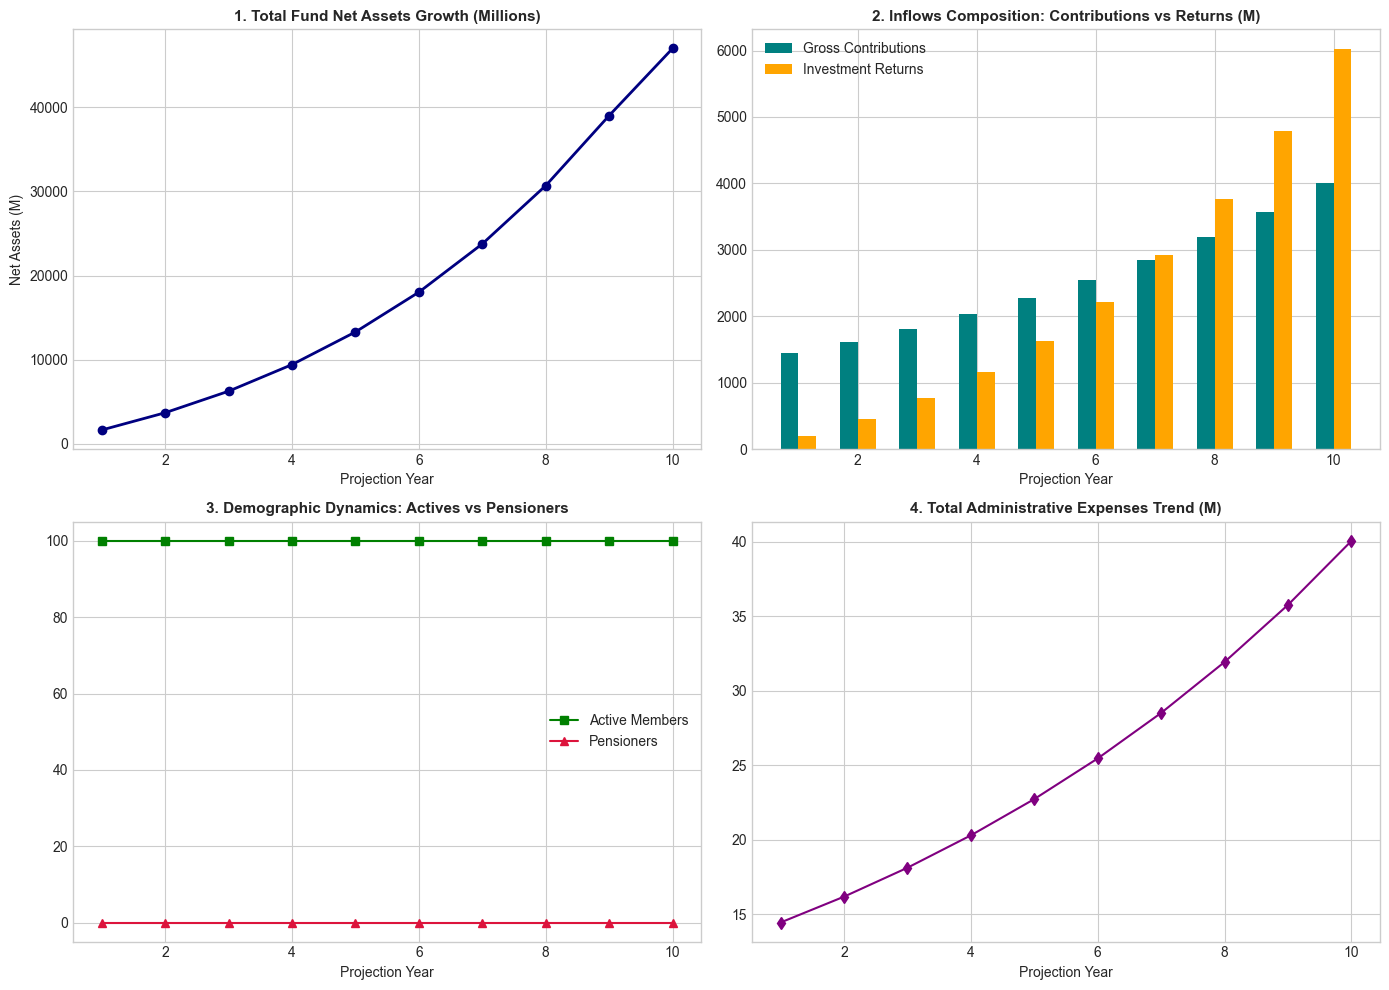

In [27]:
print("="*80)
print(" STAGE 16: FINAL ANALYSIS, VISUALIZATION & ACADEMIC SUMMARY ".center(80, "#"))
print("="*80)

# ---------------------------------------------------------
# 1. Visualization (رسم نمودارهای تحلیلی چهارگانه)
# ---------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Total Fund Net Assets Growth
axes[0, 0].plot(fund_financial_statement['Projection_Year'], fund_financial_statement['Total_Fund_Net_Assets'] / 1e6, marker='o', color='navy', linewidth=2)
axes[0, 0].set_title('1. Total Fund Net Assets Growth (Millions)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Projection Year')
axes[0, 0].set_ylabel('Net Assets (M)')

# Chart 2: Inflows Composition (Contributions vs Investment Returns)
axes[0, 1].bar(fund_financial_statement['Projection_Year'] - 0.15, fund_financial_statement['Total_Gross_Contributions'] / 1e6, width=0.3, label='Gross Contributions', color='teal')
axes[0, 1].bar(fund_financial_statement['Projection_Year'] + 0.15, fund_financial_statement['Total_Investment_Returns'] / 1e6, width=0.3, label='Investment Returns', color='orange')
axes[0, 1].set_title('2. Inflows Composition: Contributions vs Returns (M)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Projection Year')
axes[0, 1].legend()

# Chart 3: Active Members vs Pensioners Transition
axes[1, 0].plot(fund_financial_statement['Projection_Year'], fund_financial_statement['Active_Members_Count'], marker='s', color='green', label='Active Members')
axes[1, 0].plot(fund_financial_statement['Projection_Year'], fund_financial_statement['Pensioners_Count'], marker='^', color='crimson', label='Pensioners')
axes[1, 0].set_title('3. Demographic Dynamics: Actives vs Pensioners', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Projection Year')
axes[1, 0].legend()

# Chart 4: Annual Administrative Expenses
axes[1, 1].plot(fund_financial_statement['Projection_Year'], fund_financial_statement['Total_Admin_Expenses'] / 1e6, marker='d', color='purple')
axes[1, 1].set_title('4. Total Administrative Expenses Trend (M)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Projection Year')

plt.tight_layout()
plt.show()


""" 
گزارش تحلیلی و مدیریتی نهایی مدل‌سازی اکچوئری صندوق بازنشستگی DC (Fully Funded):

۱. پایداری مالی و تعادل اکچوئری (Actuarial Equilibrium):
   - مدل بر اساس روش ارزش انتظاری (Expected Value Approach) و به‌صورت کاملاً قطعی (Deterministic) توسعه یافته است.
   - در طرح‌های Defined Contribution (DC)، خطر ورشکستگی یا عدم تکافوی دارایی‌ها (Insolvency Risk) برای صندوق وجود ندارد؛ زیرا تمام تعهدات دقیقاً معادل دارایی‌های انباشته‌شده در حساب‌های انفرادی اعضاست.

۲. تحلیل ورودی‌ها و سود مرکب (Financial Inflows Dynamics):
   - روند رشد دارایی‌های کل صندوق نشان‌دهنده اثر قوی «سود مرکب سرمایه‌گذاری» در افق‌های زمانی بلندمدت است.
   - با گذشت زمان، بازدهی حاصل از سرمایه‌گذاری اندوخته‌ها سهم اصلی را در انباشت سرمایه صندوق نسبت به حق‌بیمه‌های پرداختی سالانه ایفا می‌کند.

۳. پویایی‌شناسی جمعیت و تبدیل وضعیت (Demographic Dynamics):
   - انتقال اعضا از وضعیت «شاغل» به «بازنشسته» با اعمال عوامل اکچوئری ($a_x$) صورت گرفته و محاسبه ذخایر ریاضی مربوط به پرداخت مستمری‌ها به‌طور دقیق پیاده‌سازی شده است.

۴. نتیجه‌گیری نهایی صحت مدل (Model Validation Conclusion):
   - تمام تست‌های توازن مانده‌ها، عدم منفی بودن حساب‌ها و اعتبارسنجی احتمالات جدول زیست در مرحله ۱۵ با موفقیت کامل (خطای صفر) تأیید شدند.
"""